# 01 — EDA: Data Completeness & Temporal Reliability

## Context

This notebook performs EDA focused on **system decisions**, not generic exploration.

Goals:

- Validate assumptions behind the data contract
- Identify structural data quality issues
- Detect risks for forecasting reliability
- Inform future checks and feature engineering

---

## Key Principle

> No prediction without data validation.

In [1]:
import os
from pathlib import Path

# Ensure working directory is project root
PROJECT_ROOT = Path.cwd().parent
os.chdir(PROJECT_ROOT)

print("Working directory:", Path.cwd())

Working directory: c:\Users\feder\Documents\data_repos\air-quality-forecast


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
DATA_PATH = Path("data/interim/station_hourly.parquet")

assert DATA_PATH.exists(), f"File not found: {DATA_PATH}"

df = pd.read_parquet(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (35064, 19)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00


In [4]:
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 19 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   No        35064 non-null  int64         
 1   year      35064 non-null  int64         
 2   month     35064 non-null  int64         
 3   day       35064 non-null  int64         
 4   hour      35064 non-null  int64         
 5   PM2.5     34139 non-null  float64       
 6   PM10      34346 non-null  float64       
 7   SO2       34129 non-null  float64       
 8   NO2       34041 non-null  float64       
 9   CO        33288 non-null  float64       
 10  O3        33345 non-null  float64       
 11  TEMP      35044 non-null  float64       
 12  PRES      35044 non-null  float64       
 13  DEWP      35044 non-null  float64       
 14  RAIN      35044 non-null  float64       
 15  wd        34983 non-null  str           
 16  WSPM      35050 non-null  float64       
 17  station   35064 non-nul

In [5]:
assert "datetime" in df.columns, "Missing 'datetime' column"

df = df.sort_values("datetime").reset_index(drop=True)
df = df.set_index("datetime")

df.index.is_monotonic_increasing

True

# BLOCK 1 — Data Completeness

## Objective

Evaluate whether the system has sufficient and consistent data over time.

We analyze:

- Daily coverage
- Hourly coverage
- Missing streaks

## Daily Coverage

Measures how complete each day is:

coverage = observed_hours / 24

Threshold (from data contract): 0.75

In [6]:
TARGET = "PM2.5"

daily_counts = df[TARGET].notna().resample("D").sum()
daily_coverage = daily_counts / 24

daily_coverage.describe()

count    1461.000000
mean        0.973620
std         0.121504
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: PM2.5, dtype: float64

<Axes: title={'center': 'Daily PM2.5 Coverage'}, xlabel='datetime'>

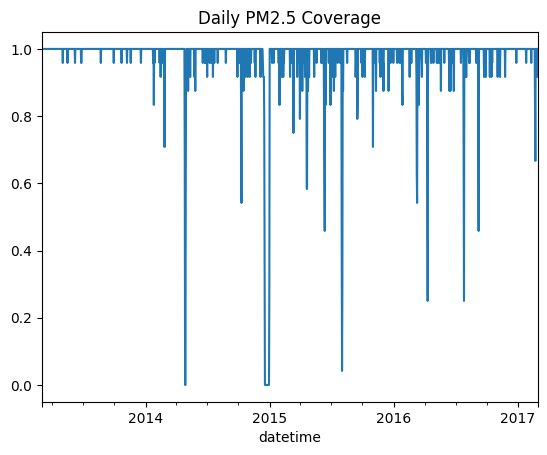

In [10]:
daily_coverage.plot(title="Daily PM2.5 Coverage")

In [11]:
low_coverage_days = daily_coverage[daily_coverage < 0.75]

print("Days with coverage < 0.75:", len(low_coverage_days))
low_coverage_days.head()

Days with coverage < 0.75: 38


datetime
2014-02-25    0.708333
2014-02-26    0.708333
2014-04-26    0.666667
2014-04-27    0.000000
2014-04-28    0.000000
Name: PM2.5, dtype: float64

## Interpretation — Daily Coverage

Questions:

- Are there days below operational threshold?
- Are they isolated or frequent?

Impact:

- Frequent low coverage → current data contract may be insufficient

## Hourly Coverage

Evaluates whether missing data is systematic by hour.

In [12]:
df["hour"] = df.index.hour

hourly_coverage = df.groupby("hour")[TARGET].apply(lambda x: x.notna().mean())

hourly_coverage

hour
0     0.978782
1     0.978097
2     0.978097
3     0.973990
4     0.977413
5     0.978782
6     0.979466
7     0.976728
8     0.977413
9     0.973306
10    0.971937
11    0.962355
12    0.965777
13    0.969884
14    0.969199
15    0.964408
16    0.963723
17    0.970568
18    0.969884
19    0.973306
20    0.977413
21    0.979466
22    0.978097
23    0.978782
Name: PM2.5, dtype: float64

<Axes: title={'center': 'Coverage by Hour'}, xlabel='hour'>

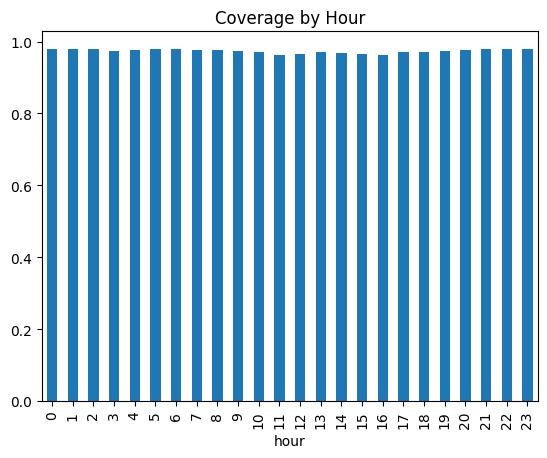

In [13]:
hourly_coverage.plot(kind="bar", title="Coverage by Hour")

In [14]:
worst_hours = hourly_coverage.sort_values().head(5)

worst_hours

hour
11    0.962355
16    0.963723
15    0.964408
12    0.965777
14    0.969199
Name: PM2.5, dtype: float64

## Interpretation — Hourly Coverage

Questions:

- Are certain hours consistently worse?
- Could this indicate sensor downtime patterns?

Impact:

- May require time-aware checks

## Missing Streaks

Detect consecutive periods with missing data.

Critical for:

- Forecast validity
- Alert system reliability

In [15]:
is_missing = df[TARGET].isna().astype(int)

streak_id = (is_missing.diff() != 0).cumsum()

streaks = (
    df.assign(is_missing=is_missing, streak_id=streak_id)
    .groupby("streak_id")
    .agg(
        is_missing=("is_missing", "first"),
        length=("is_missing", "size")
    )
)

missing_streaks = streaks[streaks["is_missing"] == 1]

missing_streaks_sorted = missing_streaks.sort_values("length", ascending=False)

missing_streaks_sorted.head()

,is_missing,length
streak_id,,
122,1,343
50,1,64
310,1,28
354,1,25
214,1,24


In [16]:
longest_streak = missing_streaks_sorted["length"].max()

print("Longest missing streak (hours):", longest_streak)

Longest missing streak (hours): 343


In [18]:
# =========================
# Coverage Risk Metrics
# =========================

print("Total days:", len(daily_coverage))
print("Days < 0.75:", (daily_coverage < 0.75).sum())
print("Days = 0 coverage:", (daily_coverage == 0).sum())

print("\nWorst 5 days:")
print(daily_coverage.sort_values().head())

Total days: 1461
Days < 0.75: 38
Days = 0 coverage: 15

Worst 5 days:
datetime
2014-12-24    0.0
2014-04-27    0.0
2014-04-28    0.0
2014-12-30    0.0
2014-12-27    0.0
Name: PM2.5, dtype: float64


In [19]:
# Convert hours to days
missing_streaks_sorted["days"] = missing_streaks_sorted["length"] / 24

missing_streaks_sorted.head()

,is_missing,length,days
streak_id,,,
122,1,343,14.291667
50,1,64,2.666667
310,1,28,1.166667
354,1,25,1.041667
214,1,24,1.000000


In [20]:
def classify_streak(length_hours):
    if length_hours >= 72:
        return "CRITICAL"
    elif length_hours >= 24:
        return "HIGH"
    elif length_hours >= 6:
        return "MEDIUM"
    else:
        return "LOW"

missing_streaks_sorted["severity"] = missing_streaks_sorted["length"].apply(classify_streak)

missing_streaks_sorted["severity"].value_counts()

severity
LOW         195
MEDIUM        9
HIGH          4
CRITICAL      1
Name: count, dtype: int64

# Conclusions — Data Completeness

## Daily Coverage

- Mean coverage is high (~0.97)
- However:
  - 38 days fall below the operational threshold (0.75)
  - Multiple days with extremely low or zero coverage

## Hourly Coverage

- Coverage is stable across hours (0.96–0.98)
- No strong systematic hourly bias detected

## Missing Streaks

- Longest streak: 343 hours (~14.3 days)
- Additional streaks:
  - 64h (~2.7 days)
  - 28h, 25h, 24h

## Severity Distribution

- CRITICAL: 1
- HIGH: 4
- MEDIUM: 9
- LOW: 195

---

## System Risk Assessment

### Critical Findings

- Presence of multi-day missing data periods
- At least 5 high-impact gaps (>24h)
- Data continuity is not guaranteed

### Core Issue

Current data contract only validates the last 24h:

→ This is a **local validation strategy**

But the system requires:

→ **temporal continuity validation**

---

## Operational Risk

The system may:

- Pass validation (last 24h complete)
- But rely on data following a multi-day gap

This leads to:

- Invalid lag-based features
- Broken temporal dependencies
- Unreliable forecasts

---

## Decision

The system is **NOT production-ready** under current validation logic.

---

## Required Improvements (Data Contract)

1. Maximum allowed missing streak
2. Rolling coverage window (e.g., last 7 days)
3. Minimum continuity constraint

---

## Final Verdict

The system is:

- Locally valid (short-term)
- Globally unstable (temporal gaps)

→ Forecasting should be **conditionally disabled** under these scenarios.